In [40]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv("../.env")

engine = create_engine(os.getenv("DATABASE_URL"))

df = pd.read_sql("SELECT * FROM participants", engine)
df.head()

,match_id,puuid,team_id,team_position,champion_id,kills,deaths,assists,gold_earned,total_minions_killed,neutral_minions_killed,total_damage_dealt_to_champions,vision_score,wards_placed,wards_killed,turret_takedowns,win
0,NA1_5565469581,JOU23TP82tQXwE_xGpDYQuzouneP5fD9nXLRN9YAZag92y...,100,TOP,82,5,8,1,9532,157,0,20545,13,6,0,0,False
1,NA1_5565469581,Fcgn58j4GOmKWxrBKiaTj6Y-yn18lgj-53bKNFjDyZAMcG...,100,JUNGLE,59,5,8,6,9333,32,108,10532,16,3,3,0,False
2,NA1_5565469581,GV6VMMnc7NYU3h416z9N4GGVnl0965GD7Jjts6vy-191o-...,100,MIDDLE,157,3,9,4,9180,155,4,12284,17,9,0,1,False
3,NA1_5565469581,9jCRKoVzQQuIllx61DgoaFrLnTRaZPQa5qGpmJRCDc0ydx...,100,BOTTOM,221,4,7,5,9806,143,0,20360,12,7,2,1,False
4,NA1_5565469581,Oc7hzHVBYoxVp1RxMk-GXXBZsFwrwy7jxjXiVWj94i0aqw...,100,UTILITY,267,2,8,12,7470,29,0,10525,68,23,10,1,False


In [41]:
df.shape

(2010, 17)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   match_id                         2010 non-null   str  
 1   puuid                            2010 non-null   str  
 2   team_id                          2010 non-null   int64
 3   team_position                    2010 non-null   str  
 4   champion_id                      2010 non-null   int64
 5   kills                            2010 non-null   int64
 6   deaths                           2010 non-null   int64
 7   assists                          2010 non-null   int64
 8   gold_earned                      2010 non-null   int64
 9   total_minions_killed             2010 non-null   int64
 10  neutral_minions_killed           2010 non-null   int64
 11  total_damage_dealt_to_champions  2010 non-null   int64
 12  vision_score                     2010 non-null   int64
 13 

In [43]:
df.describe()

,team_id,champion_id,kills,deaths,assists,gold_earned,total_minions_killed,neutral_minions_killed,total_damage_dealt_to_champions,vision_score,wards_placed,wards_killed,turret_takedowns
count,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000,2010.000000
mean,150.000000,201.982587,6.010945,6.029353,8.404975,12189.218408,134.673134,35.200498,22276.843284,32.661194,12.350249,3.140796,2.156716
std,50.012442,249.348847,4.818444,3.346526,6.196482,4355.555835,94.801614,66.913613,13091.866473,26.047992,10.172857,3.540926,2.058095
min,100.000000,1.000000,0.000000,0.000000,0.000000,509.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,100.000000,53.000000,2.000000,4.000000,4.000000,9621.750000,36.000000,0.000000,12686.750000,17.000000,6.000000,1.000000,0.000000
50%,150.000000,105.000000,5.000000,6.000000,7.000000,12244.000000,153.500000,4.000000,20439.000000,25.000000,10.000000,2.000000,2.000000
75%,200.000000,222.000000,9.000000,8.000000,12.000000,14926.250000,216.000000,14.000000,30337.500000,38.000000,14.000000,4.000000,4.000000
max,200.000000,950.000000,30.000000,19.000000,37.000000,34626.000000,380.000000,294.000000,95317.000000,184.000000,83.000000,29.000000,11.000000


In [44]:
my_df = df[df["puuid"] == "GV6VMMnc7NYU3h416z9N4GGVnl0965GD7Jjts6vy-191o-ekllnhv1AFFcp2Hk3-I2FazqQd8-X8Fw"]
my_df.shape

(201, 17)

In [45]:
my_wins = my_df[my_df["win"] == True]
my_losses = my_df[my_df["win"] == False]

print("Wins:", my_wins.shape[0])
print("Losses:", my_losses.shape[0])

Wins: 107
Losses: 94


In [46]:
my_wins[["kills", "deaths", "assists", "gold_earned", "total_minions_killed", "vision_score"]].mean()

kills                       6.803738
deaths                      4.682243
assists                     8.196262
gold_earned             13364.121495
total_minions_killed      211.542056
vision_score               26.448598
dtype: float64

In [47]:
my_losses[["kills", "deaths", "assists", "gold_earned", "total_minions_killed", "vision_score"]].mean()

kills                       4.255319
deaths                      6.223404
assists                     4.457447
gold_earned             10846.702128
total_minions_killed      193.744681
vision_score               22.521277
dtype: float64

In [48]:
timelines_df = pd.read_sql("""
    SELECT pt.match_id, pt.minute, pt.total_gold, pt.minions, pt.level, p.win
    FROM participant_timelines pt
    JOIN participants p ON pt.match_id = p.match_id AND pt.puuid = p.puuid
    WHERE pt.puuid = 'GV6VMMnc7NYU3h416z9N4GGVnl0965GD7Jjts6vy-191o-ekllnhv1AFFcp2Hk3-I2FazqQd8-X8Fw'
        AND pt.minute IN (10, 15)
    ORDER BY pt.match_id, pt.minute
""", engine)

timelines_df.head(10)

,match_id,minute,total_gold,minions,level,win
0,NA1_5494000790,10,2662,24,7,True
1,NA1_5494000790,15,4313,47,10,True
2,NA1_5496202983,10,3717,78,8,False
3,NA1_5496202983,15,5444,122,10,False
4,NA1_5496297050,10,3854,80,9,True
5,NA1_5496297050,15,5710,128,12,True
6,NA1_5497614831,10,4355,76,9,True
7,NA1_5497614831,15,6072,108,10,True
8,NA1_5497639184,10,2957,44,6,True
9,NA1_5497639184,15,5120,72,9,True


In [49]:
timelines_df.groupby(["minute", "win"])[["total_gold", "minions", "level"]].mean()

total_gold     minions      level
minute win                                      
10     False  3445.382022   71.089888   8.157303
       True   3589.663462   72.057692   8.250000
15     False  5279.213483  108.438202  10.584270
       True   5568.259615  111.125000  10.740385

In [50]:
diffs_df = pd.read_sql("""
    SELECT 
        me_pt.match_id,
        me_pt.minute,
        me_p.win,
        me_pt.total_gold - opp_pt.total_gold AS gold_diff,
        me_pt.minions    - opp_pt.minions    AS cs_diff,
        me_pt.level      - opp_pt.level      AS level_diff,
        me_pt.xp         - opp_pt.xp         AS xp_diff
    FROM participant_timelines me_pt
    JOIN participants me_p
        ON me_pt.match_id = me_p.match_id 
        AND me_pt.puuid = me_p.puuid
    JOIN participants opp_p
        ON me_p.match_id = opp_p.match_id
        AND me_p.team_position = opp_p.team_position
        AND me_p.team_id != opp_p.team_id
    JOIN participant_timelines opp_pt
        ON opp_p.match_id = opp_pt.match_id
        AND opp_pt.puuid = opp_p.puuid
        AND opp_pt.minute = me_pt.minute
    WHERE me_pt.puuid = 'GV6VMMnc7NYU3h416z9N4GGVnl0965GD7Jjts6vy-191o-ekllnhv1AFFcp2Hk3-I2FazqQd8-X8Fw'
        AND me_pt.minute IN (10, 15)
    ORDER BY me_pt.match_id, me_pt.minute
""", engine)

diffs_df.head(10)

,match_id,minute,win,gold_diff,cs_diff,level_diff,xp_diff
0,NA1_5494000790,10,True,-933,-60,-1,-1075
1,NA1_5494000790,15,True,-1251,-77,-1,-1198
2,NA1_5496202983,10,False,461,7,0,60
3,NA1_5496202983,15,False,415,17,0,120
4,NA1_5496297050,10,True,791,3,1,1052
5,NA1_5496297050,15,True,1027,21,2,2792
6,NA1_5497614831,10,True,1043,13,2,1399
7,NA1_5497614831,15,True,502,16,1,1342
8,NA1_5497639184,10,True,24,2,-1,-324
9,NA1_5497639184,15,True,1124,8,0,120


In [51]:
diffs_df.groupby(["minute", "win"])[["gold_diff", "cs_diff", "level_diff"]].mean()

gold_diff   cs_diff  level_diff
minute win                                    
10     False -174.224719 -3.955056   -0.123596
       True   187.701923  3.817308    0.125000
15     False -397.876404 -5.235955   -0.157303
       True   359.798077  6.923077    0.298077

In [52]:
diffs_df.groupby(["minute", "win"])[["gold_diff", "cs_diff", "level_diff", "xp_diff"]].mean()

gold_diff   cs_diff  level_diff     xp_diff
minute win                                                
10     False -174.224719 -3.955056   -0.123596 -130.325843
       True   187.701923  3.817308    0.125000   93.721154
15     False -397.876404 -5.235955   -0.157303 -247.483146
       True   359.798077  6.923077    0.298077  304.000000

In [53]:
pivot = diffs_df.pivot(index="match_id", columns = "minute", values = ["gold_diff", "cs_diff", "level_diff", "xp_diff"])
pivot.columns = [f"{col}_{minute}" for col , minute in pivot.columns]
pivot = pivot.reset_index()
pivot


,match_id,gold_diff_10,gold_diff_15,cs_diff_10,cs_diff_15,level_diff_10,level_diff_15,xp_diff_10,xp_diff_15
0,NA1_5494000790,-933,-1251,-60,-77,-1,-1,-1075,-1198
1,NA1_5496202983,461,415,7,17,0,0,60,120
2,NA1_5496297050,791,1027,3,21,1,2,1052,2792
3,NA1_5497614831,1043,502,13,16,2,1,1399,1342
4,NA1_5497639184,24,1124,2,8,-1,0,-324,120
...,...,...,...,...,...,...,...,...,...
188,NA1_5572700793,649,1244,30,43,1,1,927,1281
189,NA1_5573091152,101,-471,-6,-22,0,0,46,-278
190,NA1_5573296380,-8,-893,19,15,0,-1,40,-1487
191,NA1_5573942507,450,136,-2,14,0,1,54,1091


In [54]:
features_df = pivot.merge(my_df[["match_id", "champion_id", "win"]])
features_df

,match_id,gold_diff_10,gold_diff_15,cs_diff_10,cs_diff_15,level_diff_10,level_diff_15,xp_diff_10,xp_diff_15,champion_id,win
0,NA1_5494000790,-933,-1251,-60,-77,-1,-1,-1075,-1198,875,True
1,NA1_5496202983,461,415,7,17,0,0,60,120,157,False
2,NA1_5496297050,791,1027,3,21,1,2,1052,2792,157,True
3,NA1_5497614831,1043,502,13,16,2,1,1399,1342,157,True
4,NA1_5497639184,24,1124,2,8,-1,0,-324,120,157,True
...,...,...,...,...,...,...,...,...,...,...,...
188,NA1_5572700793,649,1244,30,43,1,1,927,1281,157,False
189,NA1_5573091152,101,-471,-6,-22,0,0,46,-278,777,False
190,NA1_5573296380,-8,-893,19,15,0,-1,40,-1487,157,True
191,NA1_5573942507,450,136,-2,14,0,1,54,1091,157,False


In [55]:
features_df["gold_momentum"] = features_df["gold_diff_15"] - features_df["gold_diff_10"]
features_df["cs_momentum"] = features_df["cs_diff_15"] - features_df["cs_diff_10"]
features_df["level_momentum"] = features_df["level_diff_15"] - features_df["level_diff_10"]
features_df["xp_momentum"] = features_df["xp_diff_15"] - features_df["xp_diff_10"]
features_df

,match_id,gold_diff_10,gold_diff_15,cs_diff_10,cs_diff_15,level_diff_10,level_diff_15,xp_diff_10,xp_diff_15,champion_id,win,gold_momentum,cs_momentum,level_momentum,xp_momentum
0,NA1_5494000790,-933,-1251,-60,-77,-1,-1,-1075,-1198,875,True,-318,-17,0,-123
1,NA1_5496202983,461,415,7,17,0,0,60,120,157,False,-46,10,0,60
2,NA1_5496297050,791,1027,3,21,1,2,1052,2792,157,True,236,18,1,1740
3,NA1_5497614831,1043,502,13,16,2,1,1399,1342,157,True,-541,3,-1,-57
4,NA1_5497639184,24,1124,2,8,-1,0,-324,120,157,True,1100,6,1,444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,NA1_5572700793,649,1244,30,43,1,1,927,1281,157,False,595,13,0,354
189,NA1_5573091152,101,-471,-6,-22,0,0,46,-278,777,False,-572,-16,0,-324
190,NA1_5573296380,-8,-893,19,15,0,-1,40,-1487,157,True,-885,-4,-1,-1527
191,NA1_5573942507,450,136,-2,14,0,1,54,1091,157,False,-314,16,1,1037


In [56]:
from sklearn.model_selection import train_test_split
feature_cols = [c for c in features_df.columns if c not in ["match_id", "win"]]
X = features_df[feature_cols]
y = features_df["win"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [60]:
import lightgbm as lgb

model = lgb.LGBMClassifier(n_estimators = 100, learning_rate = 0.05, num_leaves=15)
model.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 84, number of negative: 70
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 452
[LightGBM] [Info] Number of data points in the train set: 154, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545455 -> initscore=0.182322
[LightGBM] [Info] Start training from score 0.182322
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,num_leaves,15
,learning_rate,0.05
,boosting_type,'gbdt'
,max_depth,-1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [61]:
from sklearn.metrics import accuracy_score, roc_auc_score
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(f"Accuracy : {accuracy_score(Y_test, y_pred):.3f}")
print(f"AUC      : {roc_auc_score(Y_test, y_proba):.3f}")

Accuracy : 0.641
AUC      : 0.639


Matplotlib is building the font cache; this may take a moment.


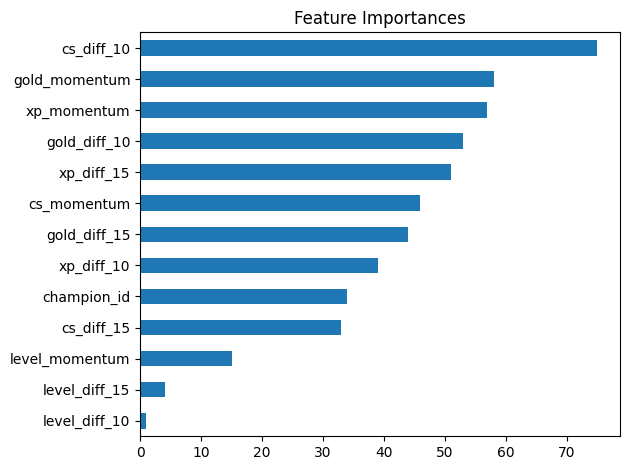

In [62]:
import matplotlib.pyplot as plt
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances.plot(kind="barh")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()